In [ ]:
import os

# --- CONFIGURAÇÃO DE CAMINHOS RELATIVOS PARA O GITHUB ---
# Defina a pasta raiz onde os dados estarão no repositório baixado
BASE_DIR = './data/TabZilla/'
ARQUIVO_SAIDA_METAMODELO = os.path.join(BASE_DIR, 'Meta_datasets_BRACIS_select.csv')

SEMENTE = 27

# Lista de datasets que serão lidos de forma relativa dentro da pasta data/
filenames_select = [
    'ada_agnostic.arff',
    'Australian_phpelnJ6y.arff',
    'Bioresponse_phpSSK7iA.arff',
    'dataset_25_colic.ORIG.arff',
    'dataset_29_credit-a_credit-approval.arff',
    'dataset_31_credit-g.arff',
    'dataset_51_heart-h.arff',
    'jasmine_file79b563a1a18.arff',
    'kc1.arff',
    'qsar-biodeg_phpGUrE90.arff'
]

In [ ]:
import os
import re
import gc
import pandas as pd
import numpy as np
import scipy.io.arff as arff
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn import tree
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import DistanceMetric

# Silencia os avisos de depreciação do Pandas
warnings.filterwarnings('ignore', category=FutureWarning)

In [ ]:
# --- 1. CONFIGURAÇÕES EXPERIMENTAIS ---
ARQUIVO_SAIDA_METAMODELO = os.path.join(BASE_DIR, 'Meta_datasets_BRACIS_select.csv')

# --- 2. FUNÇÕES DE SUPORTE ---
def clean_column_names(df):
    """Normaliza nomes de colunas para compatibilidade com os estimadores."""
    new_cols = [re.sub(r'[\[\]<>]', '_', str(col)) for col in df.columns]
    df.columns = new_cols
    return df

def get_classifiers_pool(seed):
    """
    Retorna o pool heterogêneo de 5 classificadores para o cálculo do consenso.
    Inclui modelos lineares, baseados em árvores, redes neurais e calibração de probabilidade.
    """
    return {
        'rf': RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1),
        'gb': GradientBoostingClassifier(random_state=seed),
        'lr': LogisticRegression(max_iter=1000, random_state=seed),
        'svc_linear': CalibratedClassifierCV(LinearSVC(dual='auto', random_state=seed), method='sigmoid', cv=3),
        'mlp': MLPClassifier(solver='lbfgs', random_state=seed, max_iter=1000)
    }

# --- 3. EXECUÇÃO DO EXPERIMENTO ---
lista_consolidada = []

# filenames_select deve conter a lista de caminhos relativos dos datasets desejados
for rel_path in filenames_select:
    path = os.path.join(BASE_DIR, rel_path)
    dataset_name = os.path.basename(path)

    if not os.path.exists(path):
        print(f"⚠️ Arquivo não encontrado: {dataset_name}")
        continue

    print(f"\n>>> Processando Dataset: {dataset_name}")

    try:
        # Carregamento do arquivo ARFF
        data_arff, _ = arff.loadarff(path)
        df = pd.DataFrame(data_arff)

        # Preparação dos Atributos (X) e Target (y)
        # Assume-se que o target é sempre a última coluna
        X_raw = pd.get_dummies(df.iloc[:, :-1])
        X_raw = clean_column_names(X_raw)
        y = LabelEncoder().fit_transform(df.iloc[:, -1])

        # Tratamento de valores ausentes e normalização
        imputer = SimpleImputer(strategy='mean')
        X_imputed = imputer.fit_transform(X_raw)
        X_scaled = StandardScaler().fit_transform(X_imputed)

        # Configuração da Validação Cruzada Estritamente Sincronizada
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMENTE)
        pool = get_classifiers_pool(SEMENTE)
        ih_pool_matrix = pd.DataFrame()

        # Cálculo da Instance Hardness por modelo do pool
        for name, clf in pool.items():
            print(f"   -> Avaliando {name}...")
            # Predição Out-of-Sample para evitar Overfitting na medida de dificuldade
            y_probs = cross_val_predict(clf, X_scaled, y, cv=cv, method='predict_proba', n_jobs=-1)
            # Medida de Erro: 1 - Probabilidade da classe correta
            ih_pool_matrix[name] = 1 - y_probs[np.arange(len(y)), y]

        # Geração do Ground Truth (Consenso de Erro)
        target_ih_consenso = ih_pool_matrix.mean(axis=1).values

        # Estruturação dos Metadados da Instância
        df_dataset_meta = pd.DataFrame({
            'dataset_origin': dataset_name,
            'instance_index': np.arange(len(target_ih_consenso)),
            'meta_target_err_select': target_ih_consenso
        })

        lista_consolidada.append(df_dataset_meta)

        # Gestão de Memória
        del data_arff, df, X_raw, X_imputed, X_scaled, y, ih_pool_matrix, df_dataset_meta
        gc.collect()

    except Exception as e:
        print(f"❌ Erro crítico em {dataset_name}: {str(e)}")

# --- 4. CONSOLIDAÇÃO FINAL DOS DADOS ---
if lista_consolidada:
    df_final = pd.concat(lista_consolidada, ignore_index=True)
    os.makedirs(BASE_DIR, exist_ok=True)
    df_final.to_csv(ARQUIVO_SAIDA_METAMODELO, index=False)
    print(f"\n✅ Pipeline concluído com sucesso!")
    print(f"💾 Arquivo para metamodelação salvo em: {ARQUIVO_SAIDA_METAMODELO}")
    print(f"📊 Total de instâncias processadas: {len(df_final)}")
else:
    print("\nFalha: Nenhuma instância foi processada.")


>>> Processando Dataset: ada_agnostic.arff
   -> Avaliando rf...
   -> Avaliando gb...
   -> Avaliando lr...
   -> Avaliando svc_linear...
   -> Avaliando mlp...

>>> Processando Dataset: Australian_phpelnJ6y.arff
   -> Avaliando rf...
   -> Avaliando gb...
   -> Avaliando lr...
   -> Avaliando svc_linear...
   -> Avaliando mlp...

>>> Processando Dataset: Bioresponse_phpSSK7iA.arff
   -> Avaliando rf...
   -> Avaliando gb...
   -> Avaliando lr...
   -> Avaliando svc_linear...
   -> Avaliando mlp...

>>> Processando Dataset: dataset_25_colic.ORIG.arff
   -> Avaliando rf...
   -> Avaliando gb...
   -> Avaliando lr...
   -> Avaliando svc_linear...
   -> Avaliando mlp...

>>> Processando Dataset: dataset_29_credit-a_credit-approval.arff
   -> Avaliando rf...
   -> Avaliando gb...
   -> Avaliando lr...
   -> Avaliando svc_linear...
   -> Avaliando mlp...

>>> Processando Dataset: dataset_31_credit-g.arff
   -> Avaliando rf...
   -> Avaliando gb...
   -> Avaliando lr...
   -> Avaliando svc

In [ ]:
def gower_distance(X: pd.DataFrame) -> np.ndarray:
    """Calcula a matriz de distância de Gower corrigida para evitar warnings."""
    N = len(X)
    n_feat = X.shape[1]
    cumsum_dist = np.zeros((N, N))

    for i in range(n_feat):
        feature = X.iloc[:, [i]]
        # A correção principal está no .dtypes.iloc[0]
        if feature.dtypes.iloc[0] == object or feature.dtypes.iloc[0] == 'category':
            feature_dist = DistanceMetric.get_metric('dice').pairwise(pd.get_dummies(feature))
        else:
            feature_dist = DistanceMetric.get_metric('manhattan').pairwise(feature)
            ptp = np.ptp(feature.values)
            feature_dist /= max(ptp, 1e-8)

        cumsum_dist += feature_dist / n_feat

    return cumsum_dist

In [ ]:
class ClassificationMeasures:
    def __init__(self, data: pd.DataFrame, target_col=None, ccp_alpha=None, seed=42):
        if target_col is None:
            self.target_col = data.columns[-1]
            self.y = data.iloc[:, -1]
        else:
            self.target_col = target_col
            self.y = data[target_col]

        self.data = data.reset_index(drop=True)
        self.X = self.data.drop(columns=self.target_col)
        self.N = len(data)
        self.seed = seed

        # Modelos
        self.dtc = tree.DecisionTreeClassifier(random_state=self.seed).fit(self.X.values, self.y.values)
        self.ccp_alpha = ccp_alpha if ccp_alpha is not None else 0.01
        self.dtc_pruned = tree.DecisionTreeClassifier(ccp_alpha=self.ccp_alpha, random_state=self.seed).fit(self.X.values, self.y.values)

        nb = GaussianNB()
        self.calibrated_nb = CalibratedClassifierCV(estimator=nb, method='sigmoid', cv=3).fit(self.X, self.y)

        # Matriz Gower e Vizinhança
        self.dist_matrix_gower = gower_distance(self.X)
        delta = np.diag(-np.ones(self.N))
        self.indices_gower = np.argsort(self.dist_matrix_gower + delta, axis=1)
        self.distances_gower = np.sort(self.dist_matrix_gower, axis=1)

    def k_disagreeing_neighbors(self, k: int = 5):
        indices = self.indices_gower[:, :k + 1]
        kDN = []
        for i in range(self.N):
            neighbor_labels = self.y.iloc[indices[i][1:]].values
            current_label = self.y.iloc[i]
            kDN.append(np.sum(neighbor_labels != current_label) / k)
        return np.array(kDN)

    def disjunct_size(self):
        temp_df = self.data.copy()
        temp_df['leaf_id'] = self.dtc.apply(self.X.values)
        leaf_counts = temp_df.groupby('leaf_id')['leaf_id'].transform('count') - 1
        ds = leaf_counts / max(leaf_counts.max(), 1)
        return 1 - ds.values

    def disjunct_class_percentage(self):
        temp_df = self.data.copy()
        temp_df['leaf_id'] = self.dtc_pruned.apply(self.X.values)
        leaf_stats = temp_df.groupby(['leaf_id', self.target_col]).size().unstack(fill_value=0)
        leaf_totals = leaf_stats.sum(axis=1)
        dcp_map = 1 - (leaf_stats.max(axis=1) / leaf_totals)
        return temp_df['leaf_id'].map(dcp_map).values

    def tree_depth_unpruned(self):
        # .A1 converte matriz esparsa para array 1D
        depths = self.dtc.decision_path(self.X.values).sum(axis=1).A1 - 1
        return depths / max(self.dtc.get_depth(), 1)

    def tree_depth_pruned(self):
        depths = self.dtc_pruned.decision_path(self.X.values).sum(axis=1).A1 - 1
        return depths / max(self.dtc_pruned.get_depth(), 1)

    def class_likeliood_diff(self):
        probas = self.calibrated_nb.predict_proba(self.X)
        y_indices = LabelEncoder().fit_transform(self.y.astype(str))

        prob_real = probas[np.arange(self.N), y_indices]
        mask = np.ones(probas.shape, dtype=bool)
        mask[np.arange(self.N), y_indices] = False
        prob_others_max = probas[mask].reshape(self.N, -1).max(axis=1)

        return (1 - (prob_real - prob_others_max)) / 2

    def intra_extra_ratio(self):
        N2 = np.zeros(self.N)
        for i in range(self.N):
            labels = self.y.iloc[self.indices_gower[i]].values
            current = self.y.iloc[i]

            intra_idx = np.where(labels == current)[0]
            intra_dist = self.distances_gower[i, intra_idx[1]] if len(intra_idx) > 1 else 1.0

            extra_idx = np.where(labels != current)[0]
            extra_dist = self.distances_gower[i, extra_idx[0]] if len(extra_idx) > 0 else 1.0

            N2[i] = intra_dist / max(extra_dist, 1e-15)
        return 1 - 1 / (N2 + 1)

In [ ]:
# --- BLOCO DE SINCRONIZAÇÃO E MERGE FINAL ---
all_ihms_list = []
# Arquivo de entrada gerado no passo anterior (contém dataset_origin, instance_index e o erro)
ARQUIVO_ERROS = os.path.join(BASE_DIR, 'Meta_datasets_BRACIS_select.csv')

if not os.path.exists(ARQUIVO_ERROS):
    print(f"❌ Erro: O arquivo de base {ARQUIVO_ERROS} não foi encontrado.")
else:
    # Carrega a base de erros (Ground Truth)
    df_erros_base = pd.read_csv(ARQUIVO_ERROS)

    for rel_path in filenames_select:
        dataset_name = os.path.basename(rel_path)
        path = os.path.join(BASE_DIR, rel_path)

        if not os.path.exists(path):
            print(f"⚠️ Arquivo ARFF não encontrado: {dataset_name}")
            continue

        print(f"\n>>> Calculando IHMs (Sincronização Total): {dataset_name}")

        try:
            # 1. Carregamento Integral (Sem amostragem para manter paridade com o arquivo de erros)
            data_arff, _ = arff.loadarff(path)
            df = pd.DataFrame(data_arff)

            # 2. Decodificação de strings se necessário
            for col in df.select_dtypes([object]):
                df[col] = df[col].str.decode('utf-8')

            # 3. Preparação dos dados (Tratamento de NaNs para cálculo das IHMs)
            # Assume-se o target na última coluna
            y = LabelEncoder().fit_transform(df.iloc[:, -1].astype(str))
            X_raw = pd.get_dummies(df.iloc[:, :-1])

            # Imputação necessária para métricas baseadas em árvores e vizinhança
            X_imp = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X_raw), columns=X_raw.columns)

            # 4. Cálculo das IHMs (Instance Hardness Measures)
            # Utiliza a classe ClassificationMeasures definida anteriormente
            df_to_measures = pd.concat([X_imp, pd.Series(y, name='target')], axis=1)
            measures = ClassificationMeasures(df_to_measures, target_col='target', seed=SEMENTE)

            # 5. Consolidação com Index de Instância para Merge Rigoroso
            res = pd.DataFrame({
                'dataset_origin': dataset_name,
                'instance_index': np.arange(len(df)), # Index sequencial original do ARFF
                'kDN': measures.k_disagreeing_neighbors(),
                'DS': measures.disjunct_size(),
                'DCP': measures.disjunct_class_percentage(),
                'TD_U': measures.tree_depth_unpruned(),
                'TD_P': measures.tree_depth_pruned(),
                'CLD': measures.class_likeliood_diff(),
                'N2': measures.intra_extra_ratio()
            })

            all_ihms_list.append(res)
            print(f"   [OK] {len(res)} instâncias processadas.")

        except Exception as e:
            print(f"   [ERRO] Falha no dataset {dataset_name}: {e}")

        gc.collect()

    # --- 6. UNIFICAÇÃO E EXPORTAÇÃO FINAL ---
    if all_ihms_list:
        df_all_ihms = pd.concat(all_ihms_list, ignore_index=True)

        # Merge INNER baseado na origem e na posição da linha para garantir integridade
        df_metamodelo_final = pd.merge(
            df_erros_base,
            df_all_ihms,
            on=['dataset_origin', 'instance_index'],
            how='inner'
        )

        # Sobrescreve o arquivo final com a base agora contendo Erro + IHMs
        df_metamodelo_final.to_csv(ARQUIVO_ERROS, index=False)

        print(f"\n✅ Sincronização concluída com sucesso!")
        print(f"📊 Total de instâncias na base final: {len(df_metamodelo_final)}")
        print(f"💾 Base de metadados consolidada em: {ARQUIVO_ERROS}")
    else:
        print("\n❌ Nenhuma IHM foi calculada.")


>>> Calculando IHMs (Sincronização Total): ada_agnostic.arff
   [OK] 4562 instâncias processadas.

>>> Calculando IHMs (Sincronização Total): Australian_phpelnJ6y.arff
   [OK] 690 instâncias processadas.

>>> Calculando IHMs (Sincronização Total): Bioresponse_phpSSK7iA.arff
   [OK] 3751 instâncias processadas.

>>> Calculando IHMs (Sincronização Total): dataset_25_colic.ORIG.arff
   [OK] 368 instâncias processadas.

>>> Calculando IHMs (Sincronização Total): dataset_29_credit-a_credit-approval.arff
   [OK] 690 instâncias processadas.

>>> Calculando IHMs (Sincronização Total): dataset_31_credit-g.arff
   [OK] 1000 instâncias processadas.

>>> Calculando IHMs (Sincronização Total): dataset_51_heart-h.arff
   [OK] 294 instâncias processadas.

>>> Calculando IHMs (Sincronização Total): jasmine_file79b563a1a18.arff
   [OK] 2984 instâncias processadas.

>>> Calculando IHMs (Sincronização Total): kc1.arff
   [OK] 2109 instâncias processadas.

>>> Calculando IHMs (Sincronização Total): qsar-

Metamodelagem

In [ ]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import spearmanr

# --- 1. CONFIGURAÇÕES ATUALIZADAS PARA A NOVA BASE ---
BASE_DIR = '/content/drive/MyDrive/Doutorado/BRACIS 2026/datasetsTabZilla'
# Arquivo gerado pelo bloco de sincronização (Erro + IHMs)
ARQUIVO_META = os.path.join(BASE_DIR, 'Meta_datasets_BRACIS_select.csv')
# Novo nome do alvo de predição conforme definido anteriormente
TARGET = 'meta_target_err_select'
SEMENTE = 27
IHMS_TRAD = ['kDN', 'DS', 'DCP', 'TD_U', 'TD_P', 'CLD', 'N2']

# --- 2. CARREGAMENTO ---
if not os.path.exists(ARQUIVO_META):
    print(f"❌ Erro: Arquivo {ARQUIVO_META} não encontrado. Execute a sincronização primeiro.")
else:
    df_master = pd.read_csv(ARQUIVO_META)
    # Coluna de identificação do dataset
    col_dataset = 'dataset_origin'
    datasets_disponiveis = sorted(df_master[col_dataset].unique())

    resultados_finais = []

    print(f"📊 Iniciando Metamodelação (LODO) para {len(datasets_disponiveis)} datasets...")

    for ds_nome in datasets_disponiveis:
        # Divisão LODO: Treina em todos os datasets exceto um
        df_train = df_master[df_master[col_dataset] != ds_nome].copy()
        df_test = df_master[df_master[col_dataset] == ds_nome].copy()

        # Limpeza de valores nulos no target
        df_train = df_train.dropna(subset=[TARGET])
        df_test = df_test.dropna(subset=[TARGET])

        if len(df_test) == 0: continue

        # X e y (Preenchimento de segurança para IHMs que falharam)
        X_train, y_train = df_train[IHMS_TRAD].fillna(0), df_train[TARGET]
        X_test, y_test = df_test[IHMS_TRAD].fillna(0), df_test[TARGET]

        # Padronização (Crucial para SVR e MLP)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Definição dos Experimentos
        modelos = {
            'Baseline (Média)': DummyRegressor(strategy='mean'),
            'XGBoost': XGBRegressor(n_estimators=100, max_depth=4, random_state=SEMENTE, n_jobs=-1),
            'Random Forest': RandomForestRegressor(n_estimators=100, random_state=SEMENTE, n_jobs=-1),
            'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1)
        }

        for nome_mdl, mdl in modelos.items():
            # Treino e Predição
            mdl.fit(X_train_scaled, y_train)
            preds = mdl.predict(X_test_scaled)

            # Métricas de Performance
            mae = mean_absolute_error(y_test, preds)
            r2 = r2_score(y_test, preds)

            # Correlação de Spearman (Importante para avaliar o ranking de dificuldade)
            if nome_mdl == 'Baseline (Média)' or np.unique(preds).size == 1:
                rho = 0.0
            else:
                rho, _ = spearmanr(y_test, preds)

            resultados_finais.append({
                'Dataset': ds_nome,
                'Modelo': nome_mdl,
                'MAE': mae,
                'R2': r2,
                'Spearman': rho
            })

    # --- 3. GERAÇÃO DE OUTPUTS E TABELA FINAL ---
    df_resultados = pd.DataFrame(resultados_finais)

    # Criação da Pivot Table para comparação científica (Baseline vs Metamodelos)
    tabela_comparativa = df_resultados.pivot_table(
        index='Dataset',
        columns='Modelo',
        values=['MAE', 'R2', 'Spearman']
    )

    # Reordenar colunas para facilitar a leitura no artigo
    ordem_modelos = ['Baseline (Média)', 'XGBoost', 'Random Forest', 'SVR']
    tabela_comparativa = tabela_comparativa.reindex(columns=ordem_modelos, level=1)

    # Configurações de exibição do Pandas para o artigo
    pd.set_option('display.max_rows', None)
    pd.set_option('display.float_format', '{:.4f}'.format)

    print("\n" + "="*100)
    print("RESULTADOS FINAIS BRACIS 2026: METAMODELOS VS BASELINE")
    print("="*100)
    print(tabela_comparativa)

    # Salvar resultados detalhados para análise estatística posterior
    caminho_csv = os.path.join(BASE_DIR, 'Resultados_Metamodelo_BRACIS_select.csv')
    df_resultados.to_csv(caminho_csv, index=False)
    print(f"\n💾 Tabela consolidada salva em: {caminho_csv}")

📊 Iniciando Metamodelação (LODO) para 10 datasets...

RESULTADOS FINAIS BRACIS 2026: METAMODELOS VS BASELINE
                                                      MAE          \
Modelo                                   Baseline (Média) XGBoost   
Dataset                                                             
Australian_phpelnJ6y.arff                          0.1938  0.0804   
Bioresponse_phpSSK7iA.arff                         0.1850  0.1378   
ada_agnostic.arff                                  0.2046  0.0980   
dataset_25_colic.ORIG.arff                         0.1882  0.1163   
dataset_29_credit-a_credit-approval.arff           0.1921  0.0662   
dataset_31_credit-g.arff                           0.2095  0.1089   
dataset_51_heart-h.arff                            0.2154  0.0931   
jasmine_file79b563a1a18.arff                       0.2346  0.0520   
kc1.arff                                           0.1967  0.0635   
qsar-biodeg_phpGUrE90.arff                         0.1790  0.09

In [ ]:
# --- 4. EXPORTAÇÃO PARA OVERLEAF (HTML E LATEX) ---

# 1. Gerar a Tabela Pivot consolidada (Média por Modelo)
# Isso resume o desempenho geral em todos os datasets, o que costuma ser a tabela principal do artigo
df_resumo_geral = df_resultados.groupby('Modelo')[['MAE', 'R2', 'Spearman']].mean().reindex(ordem_modelos)

# 2. Caminhos dos arquivos
caminho_html = os.path.join(BASE_DIR, 'Tabela_Resultados_BRACIS.html')
caminho_tex = os.path.join(BASE_DIR, 'Tabela_Resultados_BRACIS.tex')

# 3. Salvar em HTML (Para visualização rápida)
tabela_comparativa.to_html(caminho_html, classes='table table-striped', justify='center')

# 4. Salvar em LaTeX (Para copiar e colar no Overleaf)
# O parâmetro bold_rows=True e a formatação facilitam a leitura acadêmica
tabela_comparativa.to_latex(caminho_tex, float_format="%.4f", caption="Resultados da Metamodelagem por Dataset", label="tab:results_lodo")

print("\n" + "="*30)
print("📂 ARQUIVOS EXPORTADOS")
print("="*30)
print(f"✅ HTML: {caminho_html}")
print(f"✅ LaTeX: {caminho_tex}")
print(f"✅ CSV: {caminho_csv}")

# Exibição simplificada para avaliação rápida no console
print("\n📊 RESUMO MÉDIO DOS MODELOS (Geral):")
print(df_resumo_geral)


📂 ARQUIVOS EXPORTADOS
✅ HTML: /content/drive/MyDrive/Doutorado/BRACIS 2026/datasetsTabZilla/Tabela_Resultados_BRACIS.html
✅ LaTeX: /content/drive/MyDrive/Doutorado/BRACIS 2026/datasetsTabZilla/Tabela_Resultados_BRACIS.tex
✅ CSV: /content/drive/MyDrive/Doutorado/BRACIS 2026/datasetsTabZilla/Resultados_Metamodelo_BRACIS_select.csv

📊 RESUMO MÉDIO DOS MODELOS (Geral):
                    MAE      R2  Spearman
Modelo                                   
Baseline (Média) 0.1999 -0.1959    0.0000
XGBoost          0.0913  0.7084    0.7493
Random Forest    0.0928  0.7061    0.7230
SVR              0.1161  0.5320    0.6894


In [ ]:
import os
import re
import gc
import base64
from io import BytesIO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# --- 1. CONFIGURAÇÕES ATUALIZADAS ---
BASE_DIR = '/content/drive/MyDrive/Doutorado/BRACIS 2026/datasetsTabZilla'
ARQUIVO_META = os.path.join(BASE_DIR, 'Meta_datasets_BRACIS_select.csv')
TARGET = 'meta_target_err_select'  # Alvo sincronizado com o novo pool
SEMENTE = 27
IHMS_TRAD = ['kDN', 'DS', 'DCP', 'TD_U', 'TD_P', 'CLD', 'N2']

# --- 2. CARREGAMENTO ---
df_master = pd.read_csv(ARQUIVO_META)
col_dataset = 'dataset_origin'
datasets_disponiveis = sorted(df_master[col_dataset].unique())

print(f"✅ Base carregada: {len(datasets_disponiveis)} datasets identificados.")

# --- 3. PREPARAÇÃO DO RELATÓRIO HTML ---
html_content = f"""
<html>
<head><title>Análise Visual de Metamodelagem - BRACIS 2026</title></head>
<style>
    body {{ font-family: Arial, sans-serif; background-color: #f4f4f9; padding: 20px; }}
    .dataset-block {{ background: white; margin-bottom: 50px; padding: 20px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); }}
    h1 {{ color: #2c3e50; text-align: center; }}
    h2 {{ border-bottom: 2px solid #3498db; color: #3498db; }}
    img {{ max-width: 100%; height: auto; display: block; margin: 0 auto; }}
</style>
<body>
    <h1>Resultados da Metamodelagem (Pool de 5 Modelos)</h1>
"""

# --- 4. FUNÇÃO PARA CONVERTER PLOT EM BASE64 ---
def plot_to_base64():
    buf = BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    plt.close()
    return base64.b64encode(buf.getvalue()).decode('utf-8')

# --- 5. LOOP DE PROCESSAMENTO E VISUALIZAÇÃO ---
for ds_nome in datasets_disponiveis:
    df_ds = df_master[df_master[col_dataset] == ds_nome].copy()
    df_ds = df_ds.dropna(subset=[TARGET])

    if len(df_ds) < 10: continue # Pula datasets insuficientes

    X = df_ds[IHMS_TRAD].fillna(0)
    y = df_ds[TARGET]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Painel Visual
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'DATASET: {ds_nome}', fontsize=20, fontweight='bold', y=1.02)

    modelos = {
        'XGBoost': XGBRegressor(n_estimators=100, max_depth=4, random_state=SEMENTE, n_jobs=-1),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=SEMENTE, n_jobs=-1),
        'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1)
    }

    for i, (nome_mdl, mdl) in enumerate(modelos.items()):
        mdl.fit(X_scaled, y)
        preds = mdl.predict(X_scaled)

        # Gráfico Real vs Predito
        ax_scatter = axes[0, i]
        sns.scatterplot(x=y, y=preds, ax=ax_scatter, color='#2c3e50', alpha=0.5)
        lims = [0, 1]
        ax_scatter.plot(lims, lims, '--r', alpha=0.8, label='Ideal')
        ax_scatter.set_title(f'{nome_mdl}: Correlação', fontsize=14)
        ax_scatter.set_xlim(lims); ax_scatter.set_ylim(lims)
        ax_scatter.legend()

        # Feature Importance (Permutation para SVR)
        ax_imp = axes[1, i]
        r = permutation_importance(mdl, X_scaled, y, n_repeats=5, random_state=SEMENTE)
        imp_series = pd.Series(r.importances_mean, index=IHMS_TRAD).sort_values()

        colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(imp_series)))
        imp_series.plot(kind='barh', ax=ax_imp, color=colors, edgecolor='black')
        ax_imp.set_title(f'Importância das Metafeatures ({nome_mdl})', fontsize=12)

    plt.tight_layout()

    # Adiciona ao HTML
    img_b64 = plot_to_base64()
    html_content += f"""
    <div class="dataset-block">
        <h2>Dataset: {ds_nome}</h2>
        <img src="data:image/png;base64,{img_b64}">
    </div>
    """
    print(f"📊 Gráficos para {ds_nome} gerados.")

# --- 6. FECHAMENTO E SALVAMENTO ---
html_content += "</body></html>"
caminho_html = os.path.join(BASE_DIR, 'Analise_Visual_Pool5.html')

with open(caminho_html, 'w') as f:
    f.write(html_content)

print("\n" + "="*50)
print(f"✅ Relatório visual salvo em: {caminho_html}")

✅ Base carregada: 10 datasets identificados.
📊 Gráficos para Australian_phpelnJ6y.arff gerados.
📊 Gráficos para Bioresponse_phpSSK7iA.arff gerados.
📊 Gráficos para ada_agnostic.arff gerados.
📊 Gráficos para dataset_25_colic.ORIG.arff gerados.
📊 Gráficos para dataset_29_credit-a_credit-approval.arff gerados.
📊 Gráficos para dataset_31_credit-g.arff gerados.
📊 Gráficos para dataset_51_heart-h.arff gerados.
📊 Gráficos para jasmine_file79b563a1a18.arff gerados.
📊 Gráficos para kc1.arff gerados.
📊 Gráficos para qsar-biodeg_phpGUrE90.arff gerados.

✅ Relatório visual salvo em: /content/drive/MyDrive/Doutorado/BRACIS 2026/datasetsTabZilla/Analise_Visual_Pool5.html


In [ ]:
import os
import base64
from io import BytesIO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# --- 1. CONFIGURAÇÕES ---
# As variáveis BASE_DIR, ARQUIVO_META, TARGET, SEMENTE, IHMS_TRAD já foram definidas em células anteriores.
# Certifique-se de que BASE_DIR, ARQUIVO_META, TARGET, SEMENTE, IHMS_TRAD estão carregados na sessão.

# --- 2. CARREGAMENTO E FILTRAGEM DOS DADOS ---
df_master = pd.read_csv(ARQUIVO_META)

# Filtrar o dataset 'jasmine_file79b563a1a18.arff'
EXCLUDE_DATASET = 'jasmine_file79b563a1a18.arff'
df_filtered = df_master[df_master['dataset_origin'] != EXCLUDE_DATASET].copy()

# Limpeza de valores nulos no target e nas features
df_filtered = df_filtered.dropna(subset=[TARGET] + IHMS_TRAD)

X = df_filtered[IHMS_TRAD].fillna(0) # Preenche NaNs nas features, se houver
y = df_filtered[TARGET]

# Verificação para evitar erros com datasets vazios após a filtragem
if X.empty:
    print(f"❌ Erro: Nenhum dado restante após excluir '{EXCLUDE_DATASET}' ou dados insuficientes.")
else:
    # Padronização dos dados
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --- 3. TREINAMENTO DO MODELO (XGBoost) e CÁLCULO DE FEATURE IMPORTANCE ---
    print(f"\n📊 Treinando o modelo para calcular a Feature Importance consolidada (excluindo {EXCLUDE_DATASET})...")
    model = XGBRegressor(n_estimators=100, max_depth=4, random_state=SEMENTE, n_jobs=-1)
    model.fit(X_scaled, y)

    # Cálculo da Feature Importance usando Permutation Importance
    # Isso garante uma medida de importância mais robusta e agnóstica ao modelo
    r = permutation_importance(model, X_scaled, y, n_repeats=5, random_state=SEMENTE, n_jobs=-1)
    imp_series = pd.Series(r.importances_mean, index=IHMS_TRAD).sort_values()

    # --- 4. GERAÇÃO DO GRÁFICO ---
    plt.figure(figsize=(10, 7))
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(imp_series)))
    imp_series.plot(kind='barh', color=colors, edgecolor='black')
    plt.title(f'Importância Consolidada das Metafeatures (Excluindo {EXCLUDE_DATASET})', fontsize=16)
    plt.xlabel('Importância Média (Permutation Importance)', fontsize=12)
    plt.ylabel('Metafeature', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # --- 5. EXPORTAÇÃO PARA HTML ---
    def plot_to_base64():
        buf = BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight')
        plt.close() # Fecha a figura para liberar memória
        return base64.b64encode(buf.getvalue()).decode('utf-8')

    img_b64 = plot_to_base64()

    html_content = f"""
    <html>
    <head><title>Feature Importance Consolidada - BRACIS 2026</title></head>
    <style>
        body {{ font-family: Arial, sans-serif; background-color: #f4f4f9; padding: 20px; text-align: center; }}
        h1 {{ color: #2c3e50; }}
        img {{ max-width: 90%; height: auto; margin: 20px auto; border: 1px solid #ddd; border-radius: 5px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); }}
    </style>
    <body>
        <h1>Feature Importance Consolidada (Excluindo {EXCLUDE_DATASET})</h1>
        <img src="data:image/png;base64,{img_b64}">
        <p>Este gráfico mostra a importância média das metafeatures, calculada por Permutation Importance com XGBoost,
        considerando todos os datasets exceto o especificado.</p>
    </body>
    </html>
    """

    caminho_html_consolidado = os.path.join(BASE_DIR, 'Feature_Importance_Consolidada_BRACIS.html')
    with open(caminho_html_consolidado, 'w') as f:
        f.write(html_content)

    print(f"✅ Gráfico de Feature Importance consolidada salvo em: {caminho_html_consolidado}")



📊 Treinando o modelo para calcular a Feature Importance consolidada (excluindo jasmine_file79b563a1a18.arff)...
✅ Gráfico de Feature Importance consolidada salvo em: /content/drive/MyDrive/Doutorado/BRACIS 2026/datasetsTabZilla/Feature_Importance_Consolidada_BRACIS.html


In [ ]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import spearmanr

# --- 1. CONFIGURAÇÕES ---
BASE_DIR = '/content/drive/MyDrive/Doutorado/BRACIS 2026/datasetsTabZilla'
ARQUIVO_META = os.path.join(BASE_DIR, 'Meta_datasets_BRACIS_select.csv')
TARGET = 'meta_target_err_select'
SEMENTE = 27

# Definição das features filtradas (Excluindo TD_U, TD_P e DCP)
IHMS_SELECT = ['kDN', 'DS', 'CLD', 'N2']

# --- 2. CARREGAMENTO ---
if not os.path.exists(ARQUIVO_META):
    print(f"❌ Erro: Arquivo {ARQUIVO_META} não encontrado.")
else:
    df_master = pd.read_csv(ARQUIVO_META)
    col_dataset = 'dataset_origin'
    datasets_disponiveis = sorted(df_master[col_dataset].unique())

    resultados_finais = []

    print(f"📊 Iniciando Metamodelação (LODO) com Features Reduzidas: {IHMS_SELECT}")

    for ds_nome in datasets_disponiveis:
        # Separação LODO
        df_train = df_master[df_master[col_dataset] != ds_nome].copy()
        df_test = df_master[df_master[col_dataset] == ds_nome].copy()

        df_train = df_train.dropna(subset=[TARGET])
        df_test = df_test.dropna(subset=[TARGET])

        if len(df_test) == 0: continue

        # Seleção apenas das metafeatures filtradas
        X_train, y_train = df_train[IHMS_SELECT].fillna(0), df_train[TARGET]
        X_test, y_test = df_test[IHMS_SELECT].fillna(0), df_test[TARGET]

        # Padronização
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Modelos
        modelos = {
            'Baseline (Média)': DummyRegressor(strategy='mean'),
            'XGBoost': XGBRegressor(n_estimators=100, max_depth=4, random_state=SEMENTE, n_jobs=-1),
            'Random Forest': RandomForestRegressor(n_estimators=100, random_state=SEMENTE, n_jobs=-1),
            'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1)
        }

        for nome_mdl, mdl in modelos.items():
            mdl.fit(X_train_scaled, y_train)
            preds = mdl.predict(X_test_scaled)

            # Métricas
            mae = mean_absolute_error(y_test, preds)
            r2 = r2_score(y_test, preds)

            if nome_mdl == 'Baseline (Média)' or np.unique(preds).size == 1:
                rho = 0.0
            else:
                rho, _ = spearmanr(y_test, preds)

            resultados_finais.append({
                'Dataset': ds_nome,
                'Modelo': nome_mdl,
                'MAE': mae,
                'R2': r2,
                'Spearman': rho
            })

    # --- 3. CONSOLIDAÇÃO E OUTPUT ---
    df_resultados = pd.DataFrame(resultados_finais)
    tabela_comparativa = df_resultados.pivot_table(
        index='Dataset',
        columns='Modelo',
        values=['MAE', 'R2', 'Spearman']
    )

    ordem_modelos = ['Baseline (Média)', 'XGBoost', 'Random Forest', 'SVR']
    tabela_comparativa = tabela_comparativa.reindex(columns=ordem_modelos, level=1)

    # Exibição e Salvamento
    pd.set_option('display.max_rows', None)
    pd.set_option('display.float_format', '{:.4f}'.format)

    print("\n" + "="*80)
    print("RESULTADOS COM FEATURES REDUZIDAS (kDN, N2, DS, CLD)")
    print("="*80)
    print(tabela_comparativa)

    # Exportação para Documentação
    caminho_csv = os.path.join(BASE_DIR, 'Resultados_Metamodelo_Reduzido.csv')
    caminho_html = os.path.join(BASE_DIR, 'Resultados_Metamodelo_Reduzido.html')

    df_resultados.to_csv(caminho_csv, index=False)
    tabela_comparativa.to_html(caminho_html)

    print(f"\n💾 Arquivos salvos em: {BASE_DIR}")

📊 Iniciando Metamodelação (LODO) com Features Reduzidas: ['kDN', 'DS', 'CLD', 'N2']

RESULTADOS COM FEATURES REDUZIDAS (kDN, DS, CLD)
                                                      MAE          \
Modelo                                   Baseline (Média) XGBoost   
Dataset                                                             
Australian_phpelnJ6y.arff                          0.1938  0.0862   
Bioresponse_phpSSK7iA.arff                         0.1850  0.1251   
ada_agnostic.arff                                  0.2046  0.0993   
dataset_25_colic.ORIG.arff                         0.1882  0.1192   
dataset_29_credit-a_credit-approval.arff           0.1921  0.0743   
dataset_31_credit-g.arff                           0.2095  0.1085   
dataset_51_heart-h.arff                            0.2154  0.0956   
jasmine_file79b563a1a18.arff                       0.2346  0.0784   
kc1.arff                                           0.1967  0.0589   
qsar-biodeg_phpGUrE90.arff            

Carregando dados sincronizados...
Treinando Regressão Linear Global...


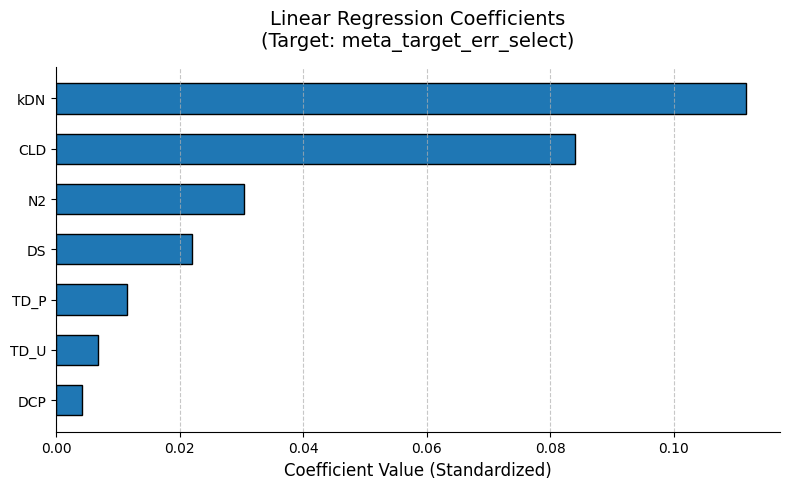

Treinando Random Forest Global...


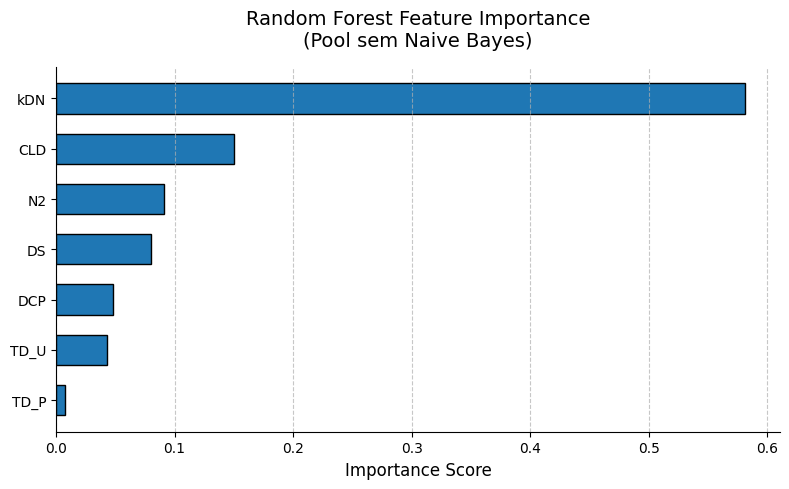


✨ GRÁFICOS ATUALIZADOS COM SUCESSO!
Salvos em:
- /content/drive/MyDrive/Doutorado/BRACIS 2026/datasetsTabZilla/feat_imp_lr_select.png
- /content/drive/MyDrive/Doutorado/BRACIS 2026/datasetsTabZilla/feat_imp_rf_select.png


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# --- 1. CONFIGURAÇÕES E CARREGAMENTOS ---
BASE_DIR = '/content/drive/MyDrive/Doutorado/BRACIS 2026/datasetsTabZilla'
# Atualizado para a nova base sem Naive Bayes
ARQUIVO_META = os.path.join(BASE_DIR, 'Meta_datasets_BRACIS_select.csv')
# Atualizado para o novo target de consenso
TARGET = 'meta_target_err_select'
SEMENTE = 27
IHMs_TRAD = ['kDN', 'DS', 'DCP', 'TD_U', 'TD_P', 'CLD', 'N2']

print("Carregando dados sincronizados...")
df_master = pd.read_csv(ARQUIVO_META)

# Remove valores nulos no target para garantir integridade
df_clean = df_master.dropna(subset=[TARGET])

X = df_clean[IHMs_TRAD].fillna(0)
y = df_clean[TARGET]

# ---------------------------------------------------------
# 2. REGRESSÃO LINEAR GLOBAL (Comparação de Coeficientes)
# ---------------------------------------------------------
print("Treinando Regressão Linear Global...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LinearRegression()
lr.fit(X_scaled, y)

df_lr_imp = pd.DataFrame({
    'Feature': IHMs_TRAD,
    'Coeficiente': lr.coef_
}).sort_values(by='Coeficiente', ascending=True)

plt.figure(figsize=(8, 5))
cores_lr = ['#d62728' if x < 0 else '#1f77b4' for x in df_lr_imp['Coeficiente']]
plt.barh(df_lr_imp['Feature'], df_lr_imp['Coeficiente'], color=cores_lr, edgecolor='black', height=0.6)
plt.title(f'Linear Regression Coefficients\n(Target: {TARGET})', fontsize=14, pad=15)
plt.xlabel('Coefficient Value (Standardized)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()

caminho_lr = os.path.join(BASE_DIR, 'feat_imp_lr_select.png')
plt.savefig(caminho_lr, dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# 3. RANDOM FOREST GLOBAL (Importância por Gini/Impureza)
# ---------------------------------------------------------
print("Treinando Random Forest Global...")
rf = RandomForestRegressor(random_state=SEMENTE, n_jobs=-1)
rf.fit(X, y)

df_rf_imp = pd.DataFrame({
    'Feature': IHMs_TRAD,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(df_rf_imp['Feature'], df_rf_imp['Importance'], color='#1f77b4', edgecolor='black', height=0.6)
plt.title(f'Random Forest Feature Importance\n(Pool sem Naive Bayes)', fontsize=14, pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()

caminho_rf = os.path.join(BASE_DIR, 'feat_imp_rf_select.png')
plt.savefig(caminho_rf, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✨ GRÁFICOS ATUALIZADOS COM SUCESSO!")
print(f"Salvos em:\n- {caminho_lr}\n- {caminho_rf}")

Processando Random Forest...
Processando XGBoost...
Processando SVR...


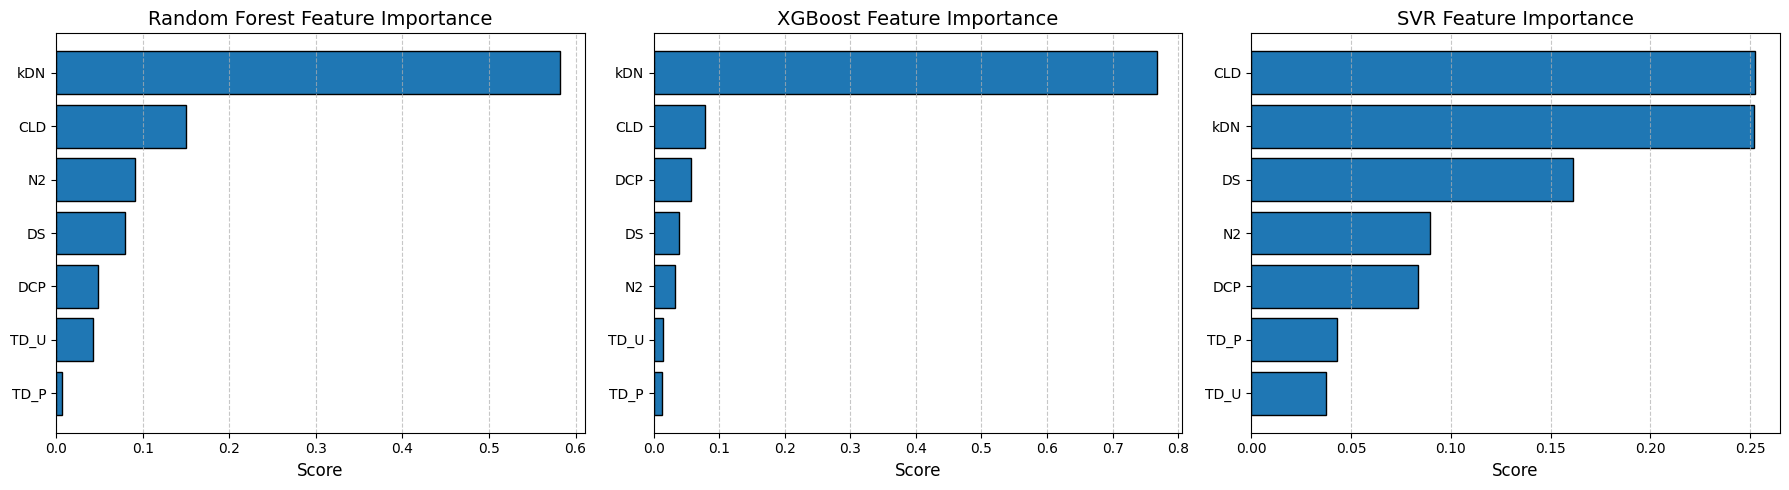


✨ Figura salva em: /content/drive/MyDrive/Doutorado/BRACIS 2026/datasetsTabZilla/combined_feature_importance.png


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

# --- 1. CONFIGURAÇÕES E CARREGAMENTOS ---
BASE_DIR = '/content/drive/MyDrive/Doutorado/BRACIS 2026/datasetsTabZilla'
ARQUIVO_META = os.path.join(BASE_DIR, 'Meta_datasets_BRACIS_select.csv')
TARGET = 'meta_target_err_select'
SEMENTE = 27
IHMs_TRAD = ['kDN', 'DS', 'DCP', 'TD_U', 'TD_P', 'CLD', 'N2']

df_master = pd.read_csv(ARQUIVO_META)
df_clean = df_master.dropna(subset=[TARGET])

X = df_clean[IHMs_TRAD].fillna(0)
y = df_clean[TARGET]

# Padronização (Essencial para SVR)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=IHMs_TRAD)

# --- 2. DEFINIÇÃO DOS MODELOS ---
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=SEMENTE, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=4, random_state=SEMENTE, n_jobs=-1),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1)
}

# --- 3. CÁLCULO E PLOTAGEM ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    print(f"Processando {name}...")

    if name == 'SVR':
        # SVR RBF não tem .feature_importances_, usamos Permutation Importance
        model.fit(X_scaled, y)
        result = permutation_importance(model, X_scaled, y, n_repeats=10, random_state=SEMENTE)
        importance = result.importances_mean
    else:
        # RF e XGBoost usam a importância nativa (Gini/Gain)
        model.fit(X, y)
        importance = model.feature_importances_

    # Organizar para o gráfico
    df_imp = pd.DataFrame({'Feature': IHMs_TRAD, 'Importance': importance}).sort_values(by='Importance', ascending=True)

    # Plot
    axes[i].barh(df_imp['Feature'], df_imp['Importance'], color='#1f77b4', edgecolor='black')
    axes[i].set_title(f'{name} Feature Importance', fontsize=14)
    axes[i].set_xlabel('Score', fontsize=12)
    axes[i].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
caminho_saida = os.path.join(BASE_DIR, 'combined_feature_importance.png')
plt.savefig(caminho_saida, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✨ Figura salva em: {caminho_saida}")